In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from src.evaluation          import (
    evaluate_on_test, plot_confusion_matrices, plot_roc_curves,
    plot_feature_importance, plot_metrics_heatmap
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
SAMPLE_SIZE  = 100_000
RAW_PATH     = '../data/raw/global_youtube_creator_data_large.csv'
FIGURES_DIR  = '../reports/figures'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


In [2]:
import os, pickle
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(''))
while PROJECT_ROOT.name != 'Proyecto_Final_ML':
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
print('Working dir:', PROJECT_ROOT)

FIGURES_DIR = str(PROJECT_ROOT / 'reports' / 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

with open(PROJECT_ROOT / 'data' / 'processed' / 'fase3_artifacts.pkl', 'rb') as f:
    a3 = pickle.load(f)

X_test_proc        = a3['X_test_proc']
y_test             = a3['y_test']
feature_names_proc = a3['feature_names_proc']

with open(PROJECT_ROOT / 'data' / 'processed' / 'fase4_artifacts.pkl', 'rb') as f:
    a4 = pickle.load(f)

trained_models = a4['trained_models']
best_models    = a4['best_models']
cv_results     = a4['cv_results']

print('Todo cargado para Fase 5')

Working dir: c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML
Todo cargado para Fase 5


---
# FASE 5 | EVALUACION (Evaluation)
---

## 5.1 Metricas en el conjunto de prueba

In [3]:
test_results = evaluate_on_test(trained_models, X_test_proc, y_test.values)


  Regresion Logistica
              precision    recall  f1-score   support

    No Viral       0.62      0.61      0.61      9999
       Viral       0.61      0.63      0.62      9999

    accuracy                           0.62     19998
   macro avg       0.62      0.62      0.62     19998
weighted avg       0.62      0.62      0.62     19998


  Random Forest
              precision    recall  f1-score   support

    No Viral       0.66      0.51      0.58      9999
       Viral       0.60      0.74      0.66      9999

    accuracy                           0.63     19998
   macro avg       0.63      0.63      0.62     19998
weighted avg       0.63      0.63      0.62     19998


  Gradient Boosting
              precision    recall  f1-score   support

    No Viral       0.65      0.53      0.59      9999
       Viral       0.61      0.72      0.66      9999

    accuracy                           0.63     19998
   macro avg       0.63      0.63      0.62     19998
weighted avg 

In [4]:
print('\nTabla de Metricas - Conjunto de Prueba:')
display(test_results.round(4))


Tabla de Metricas - Conjunto de Prueba:


,Accuracy,F1,ROC-AUC,Precision,Recall
Modelo,,,,,
Regresion Logistica,0.6157,0.6195,0.6669,0.6134,0.6258
Random Forest,0.6252,0.6626,0.6799,0.6025,0.7361
Gradient Boosting,0.6251,0.6573,0.6807,0.6053,0.7191
Hist Gradient Boosting,0.6233,0.6571,0.6803,0.6030,0.7219


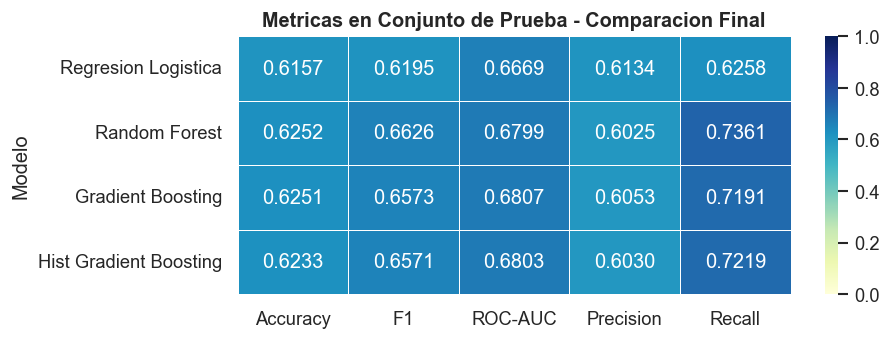

[INFO] Figura guardada: c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML\reports\figures/metrics_heatmap.png


In [5]:
plot_metrics_heatmap(test_results, save_path=f'{FIGURES_DIR}/metrics_heatmap.png')

## 5.2 Matrices de confusión

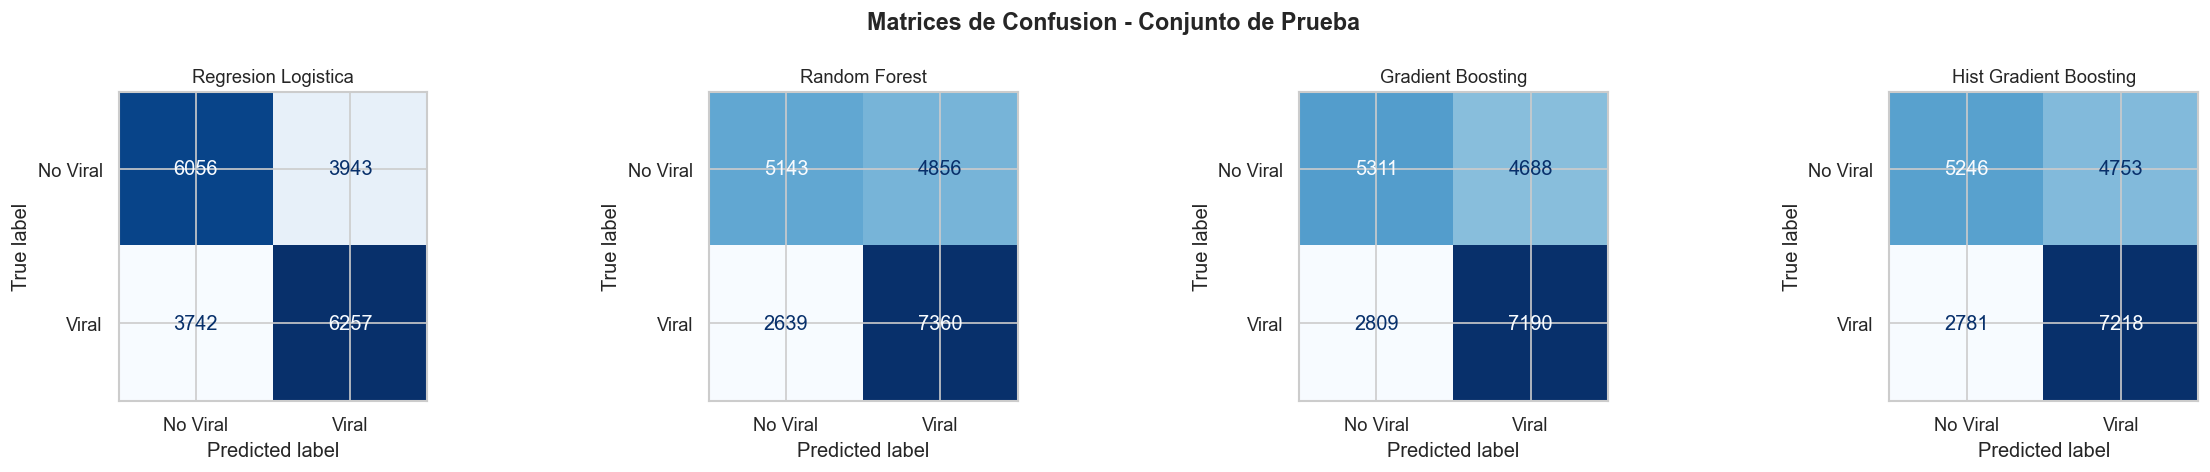

[INFO] Figura guardada: c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML\reports\figures/confusion_matrices.png


In [6]:
plot_confusion_matrices(trained_models, X_test_proc, y_test.values,
                         save_path=f'{FIGURES_DIR}/confusion_matrices.png')

## 5.3 Curvas ROC

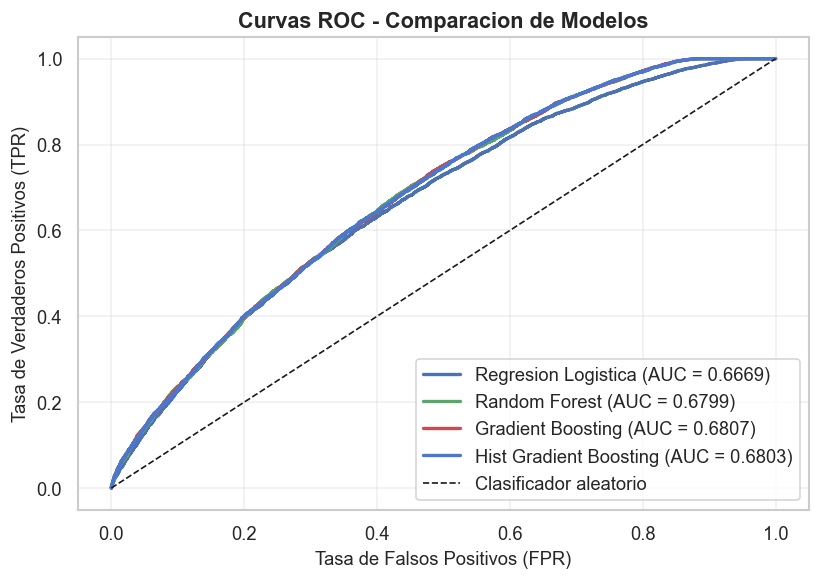

[INFO] Figura guardada: c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML\reports\figures/roc_curves.png


In [7]:
plot_roc_curves(trained_models, X_test_proc, y_test.values,
                save_path=f'{FIGURES_DIR}/roc_curves.png')

## 5.4 Importancia de caracteristicas

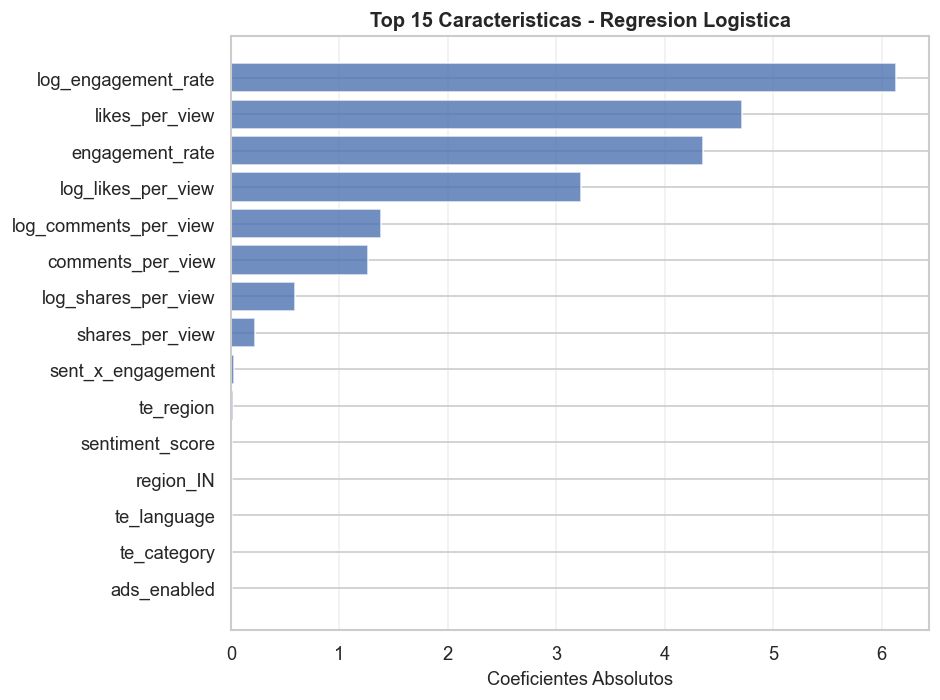

[INFO] Figura guardada: c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML\reports\figures/feature_importance_regresion_logistica.png


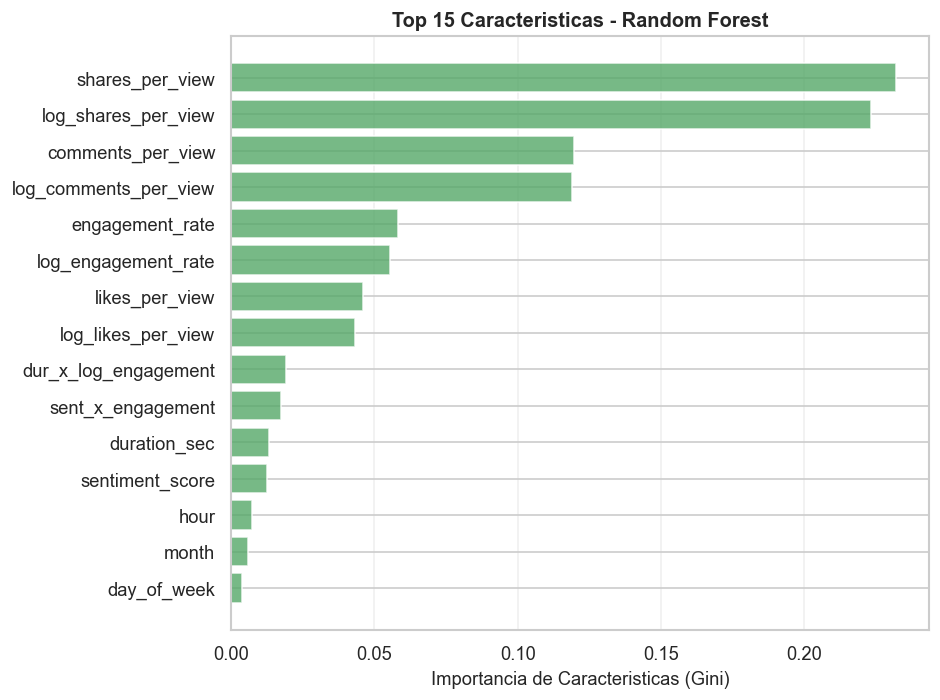

[INFO] Figura guardada: c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML\reports\figures/feature_importance_random_forest.png


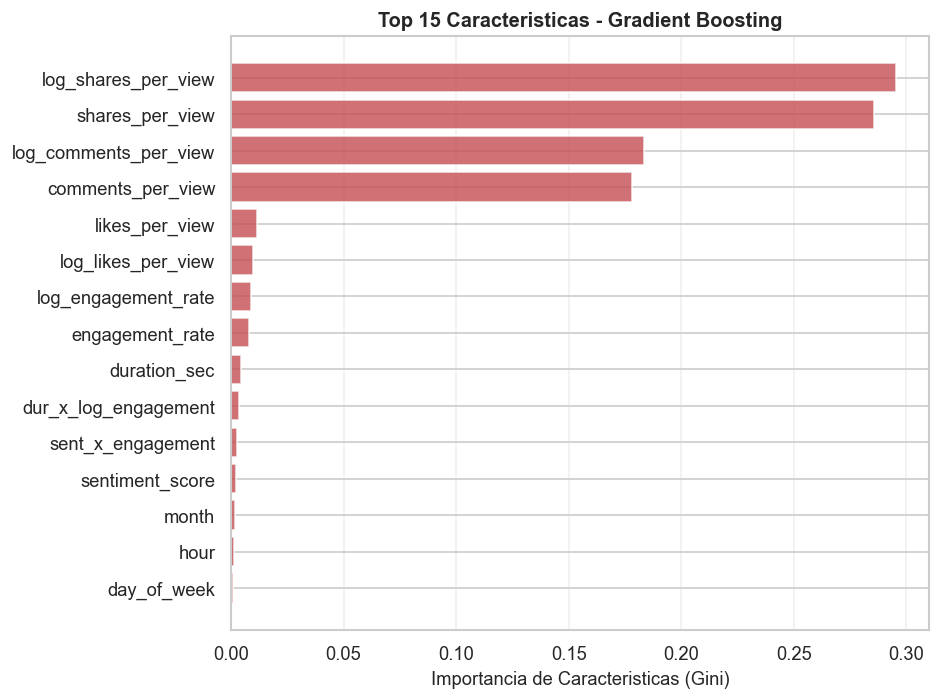

[INFO] Figura guardada: c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML\reports\figures/feature_importance_gradient_boosting.png
[WARN] El modelo Hist Gradient Boosting no tiene importancias ni coeficientes.


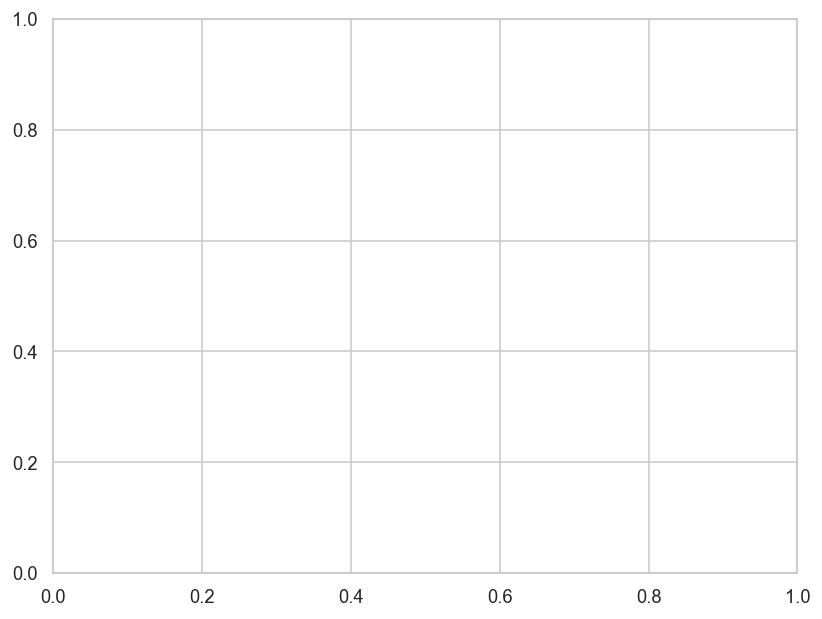

In [8]:
for name, model in trained_models.items():
    plot_feature_importance(
        model, feature_names_proc, name, top_n=15,
        save_path=f'{FIGURES_DIR}/feature_importance.png'
    )

## 5.5 Comparación global y selección del mejor modelo

In [9]:
summary = pd.DataFrame({
    'CV ROC-AUC': cv_results['ROC-AUC (val)'],
    'Test ROC-AUC': test_results['ROC-AUC'],
    'CV F1': cv_results['F1 (val)'],
    'Test F1': test_results['F1'],
    'Test Accuracy': test_results['Accuracy'],
})

print('Comparacion CV vs Conjunto de Prueba:')
display(summary.round(4))

mejor_modelo = test_results['ROC-AUC'].idxmax()
mejor_auc    = test_results.loc[mejor_modelo, 'ROC-AUC']

print(f'\nMejor modelo (por ROC-AUC en prueba): {mejor_modelo}')
print(f'ROC-AUC = {mejor_auc:.4f}')

Comparacion CV vs Conjunto de Prueba:


,CV ROC-AUC,Test ROC-AUC,CV F1,Test F1,Test Accuracy
Regresion Logistica,0.6650,0.6669,0.6191,0.6195,0.6157
Random Forest,0.6788,0.6799,0.6612,0.6626,0.6252
Gradient Boosting,0.6792,0.6807,0.6559,0.6573,0.6251
Hist Gradient Boosting,0.6788,0.6803,0.6560,0.6571,0.6233



Mejor modelo (por ROC-AUC en prueba): Gradient Boosting
ROC-AUC = 0.6807


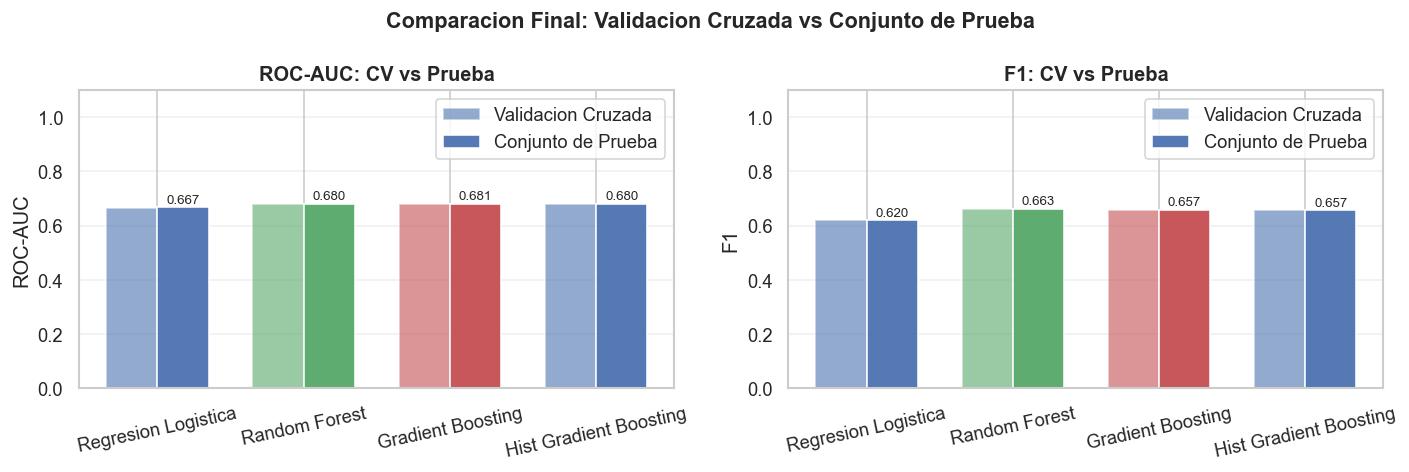

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

model_colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, metric in zip(axes, ['ROC-AUC', 'F1']):
    cv_vals   = summary[f'CV {metric}'].values
    test_vals = summary[f'Test {metric}'].values
    x = np.arange(len(summary))
    w = 0.35

    bars1 = ax.bar(x - w/2, cv_vals,   w, label='Validacion Cruzada',
                   color=model_colors, alpha=0.6)
    bars2 = ax.bar(x + w/2, test_vals, w, label='Conjunto de Prueba',
                   color=model_colors, alpha=0.95)

    ax.set_xticks(x)
    ax.set_xticklabels(summary.index, rotation=12)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{metric}: CV vs Prueba', fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    for bar, val in zip(bars2, test_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparacion Final: Validacion Cruzada vs Conjunto de Prueba',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comparacion_final.png', bbox_inches='tight')
plt.show()

## 5.6 Optimización del Umbral de Decisión

Por defecto los clasificadores usan umbral = 0.5. Optimizarlo maximiza el F1-score
en el conjunto de prueba sin reentrenar el modelo. Esto es especialmente útil cuando
el costo de falsos positivos y falsos negativos no es simétrico.


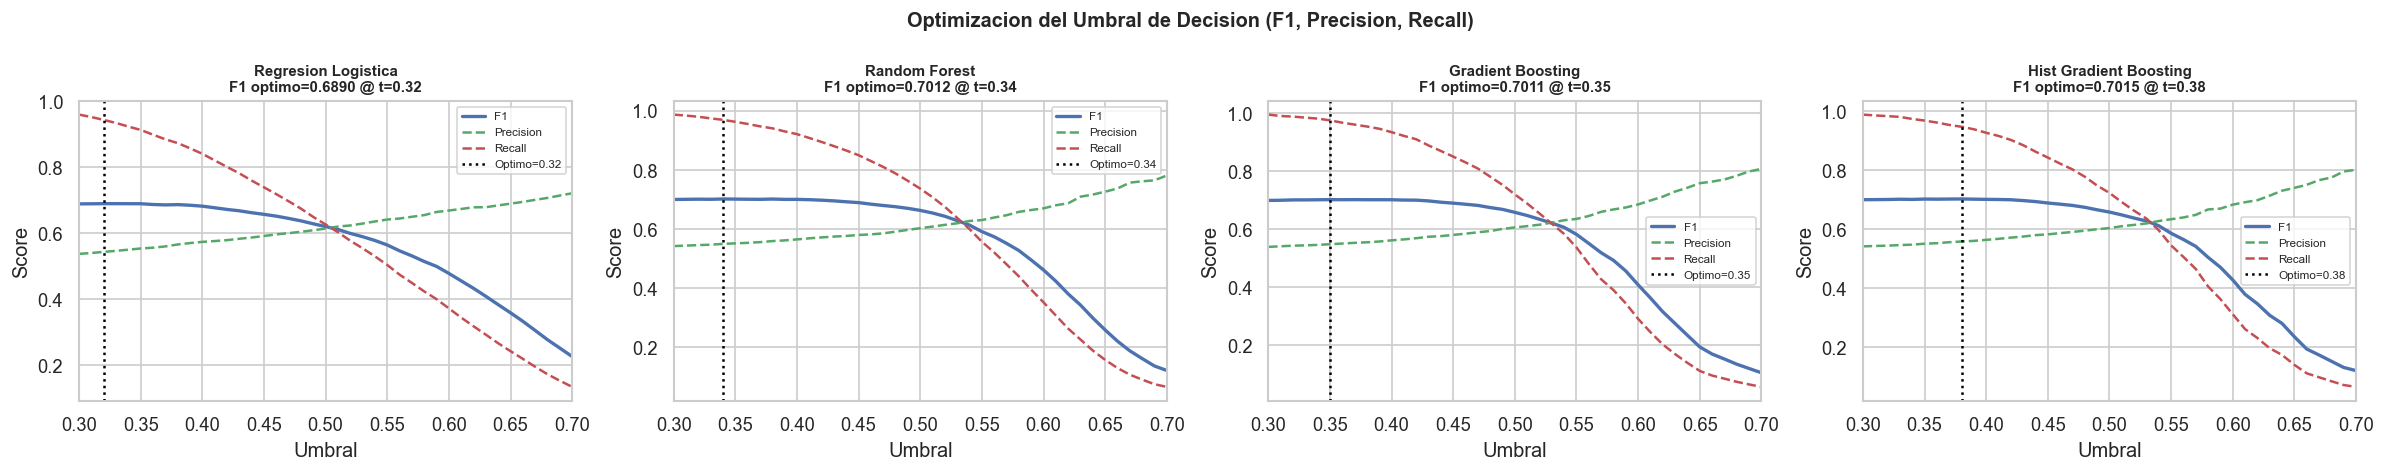


Umbrales optimos por modelo:
  Regresion Logistica           : umbral=0.32  F1=0.6890
  Random Forest                 : umbral=0.34  F1=0.7012
  Gradient Boosting             : umbral=0.35  F1=0.7011
  Hist Gradient Boosting        : umbral=0.38  F1=0.7015


In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score

umbral_results = {}
thresholds     = np.arange(0.30, 0.71, 0.01)

fig, axes = plt.subplots(1, len(trained_models), figsize=(5 * len(trained_models), 4))
if len(trained_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, trained_models.items()):
    proba = model.predict_proba(X_test_proc)[:, 1]

    f1s, precs, recs = [], [], []
    for t in thresholds:
        preds = (proba >= t).astype(int)
        f1s.append(f1_score(y_test, preds, zero_division=0))
        precs.append(precision_score(y_test, preds, zero_division=0))
        recs.append(recall_score(y_test, preds, zero_division=0))

    best_t = thresholds[np.argmax(f1s)]
    best_f1 = max(f1s)
    umbral_results[name] = {'umbral_optimo': best_t, 'F1_optimo': best_f1}

    ax.plot(thresholds, f1s,   label='F1',        color='#4C72B0', lw=2)
    ax.plot(thresholds, precs, label='Precision',  color='#55A868', lw=1.5, linestyle='--')
    ax.plot(thresholds, recs,  label='Recall',     color='#C44E52', lw=1.5, linestyle='--')
    ax.axvline(best_t, color='black', linestyle=':', lw=1.5, label=f'Optimo={best_t:.2f}')
    ax.set_title(f'{name}\nF1 optimo={best_f1:.4f} @ t={best_t:.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Umbral'); ax.set_ylabel('Score')
    ax.legend(fontsize=7); ax.set_xlim(0.30, 0.70)

plt.suptitle('Optimizacion del Umbral de Decision (F1, Precision, Recall)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/threshold_optimization.png', bbox_inches='tight')
plt.show()

print('\nUmbrales optimos por modelo:')
for name, res in umbral_results.items():
    print(f'  {name:30}: umbral={res["umbral_optimo"]:.2f}  F1={res["F1_optimo"]:.4f}')

## 5.7 Curva de Calibración

La curva de calibración (*reliability diagram*) compara la probabilidad media predicha por el modelo contra la frecuencia real de positivos en cada bin. Un modelo **perfectamente calibrado** sigue la diagonal punteada.

- Curvas **por encima** de la diagonal → el modelo subestima la probabilidad real.
- Curvas **por debajo** → el modelo sobreestima la probabilidad real.

Una buena calibración es especialmente importante cuando las probabilidades se usan para tomar decisiones de negocio (no solo la clase predicha).

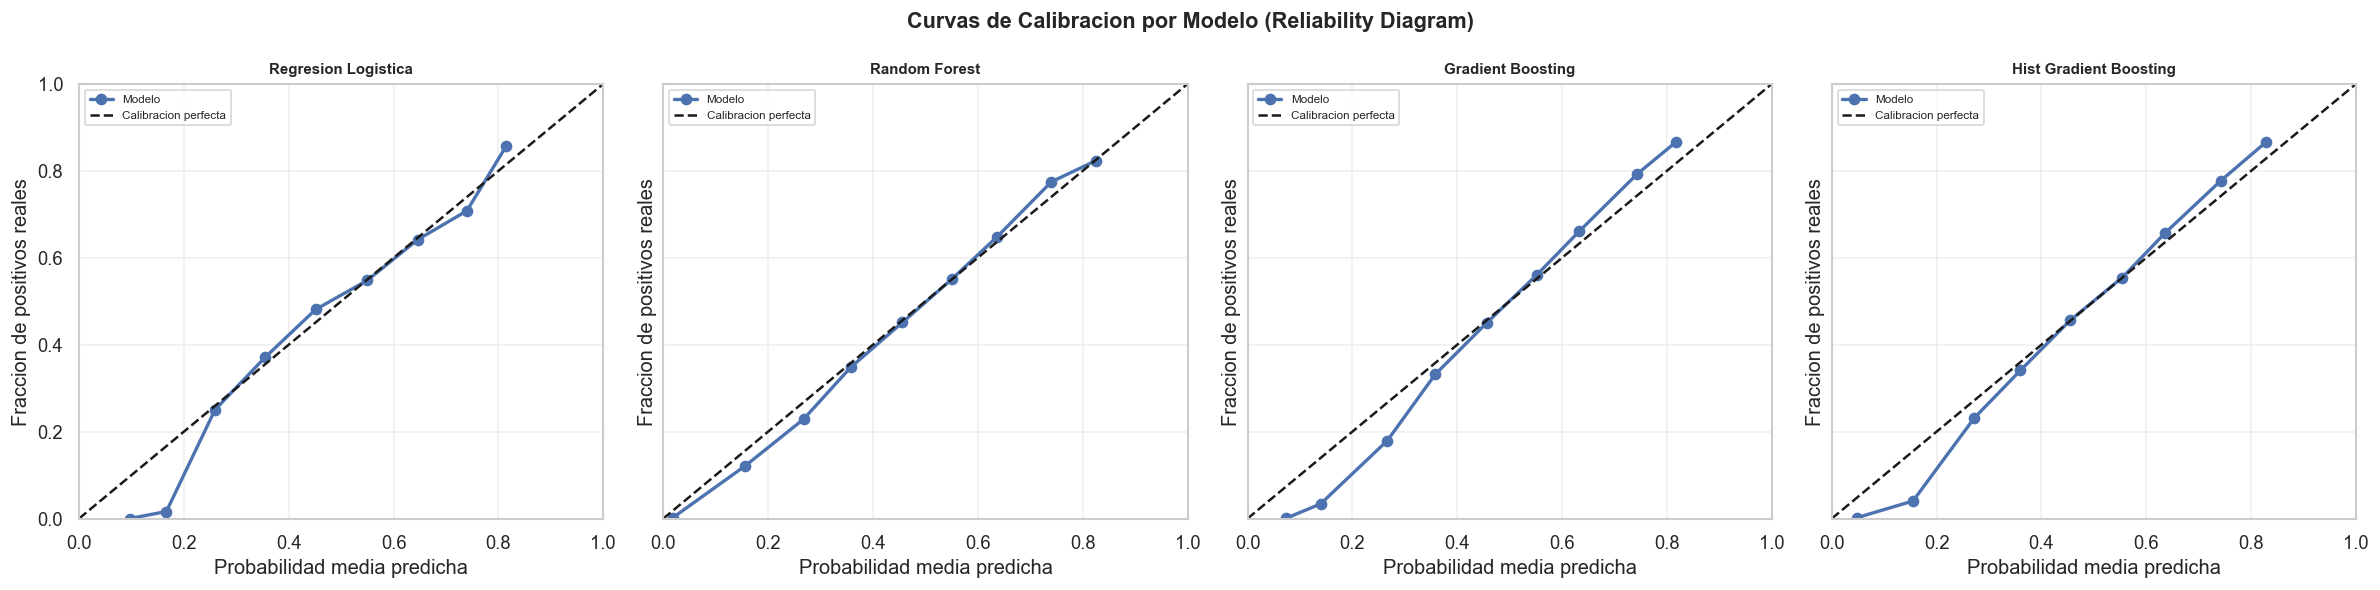

Curvas de calibracion guardadas.


In [ ]:
from sklearn.calibration import calibration_curve

with open(PROJECT_ROOT / 'data' / 'processed' / 'fase3_artifacts.pkl', 'rb') as f:
    _a3 = pickle.load(f)
X_train_proc = _a3['X_train_proc']
y_train      = _a3['y_train']

n_models = len(trained_models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, trained_models.items()):
    proba = model.predict_proba(X_test_proc)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='uniform')

    ax.plot(mean_pred, frac_pos, 'o-', color='#4C72B0', lw=2, label='Modelo')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Calibracion perfecta')
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Probabilidad media predicha')
    ax.set_ylabel('Fraccion de positivos reales')
    ax.legend(fontsize=7)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de Calibracion por Modelo (Reliability Diagram)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/calibration_curves.png', bbox_inches='tight')
plt.show()
print('Curvas de calibracion guardadas.')


## 5.8 Curva de Aprendizaje

La curva de aprendizaje muestra cómo evoluciona el ROC-AUC a medida que se incrementa el tamaño del conjunto de entrenamiento. Permite diagnosticar dos patrones clásicos:

- **Alto sesgo (underfitting)**: las curvas de entrenamiento y validación convergen en un valor bajo → el modelo necesita más complejidad.
- **Alta varianza (overfitting)**: gran brecha persistente entre entrenamiento y validación → el modelo se beneficiaría de más datos o mayor regularización.

Se excluye Gradient Boosting clásico por su alto costo computacional (≈198 s por fold).

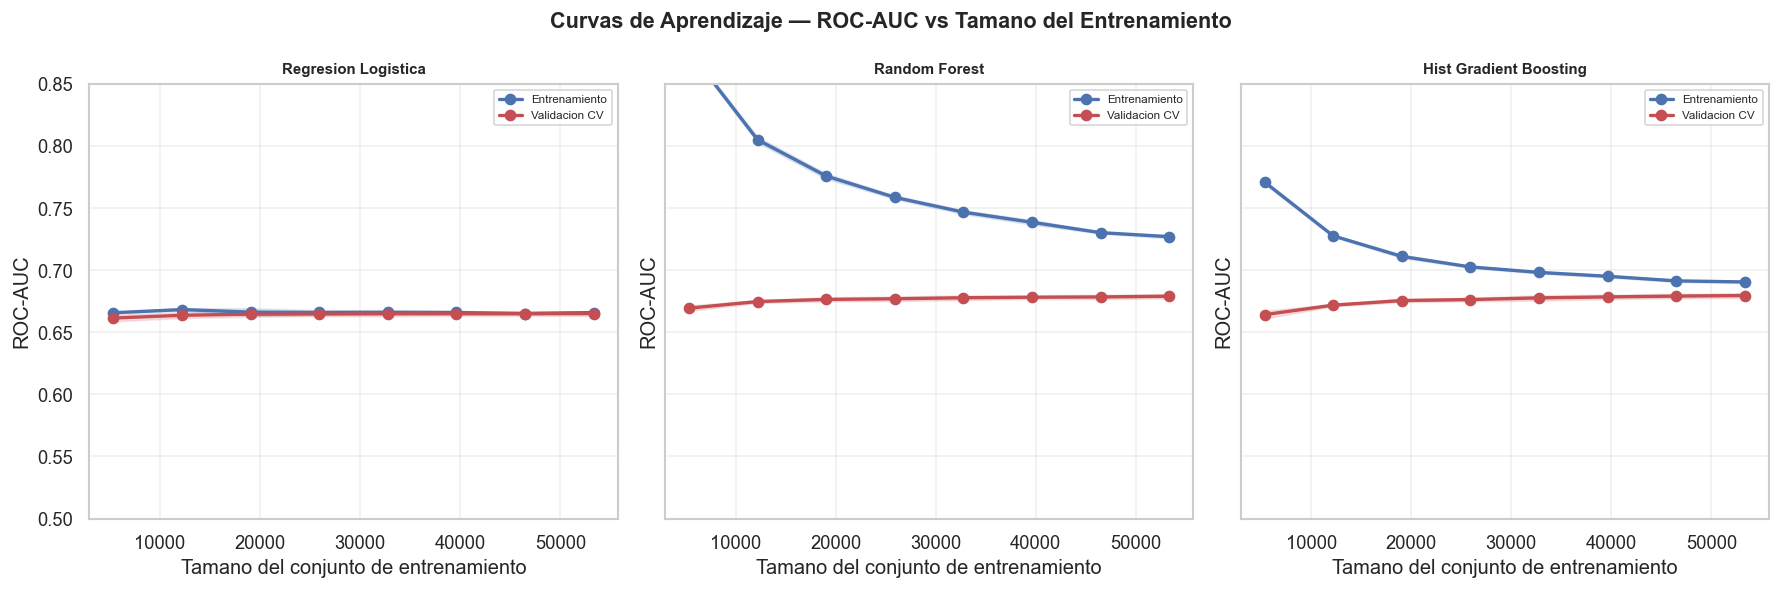

Curvas de aprendizaje guardadas.


In [13]:
from sklearn.model_selection import learning_curve

# Excluye Gradient Boosting clasico (~198 s por fold) para mantener tiempo razonable
models_lc = {k: v for k, v in trained_models.items() if k != 'Gradient Boosting'}

train_sizes_pct = np.linspace(0.10, 1.0, 8)

fig, axes = plt.subplots(1, len(models_lc), figsize=(5 * len(models_lc), 5), sharey=True)
if len(models_lc) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, models_lc.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_proc, y_train.values,
        train_sizes=train_sizes_pct,
        cv=3, scoring='roc_auc',
        n_jobs=-1
    )
    tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    va_mean, va_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='#4C72B0', lw=2, label='Entrenamiento')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='#4C72B0')
    ax.plot(train_sizes, va_mean, 'o-', color='#C44E52', lw=2, label='Validacion CV')
    ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.15, color='#C44E52')

    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Tamano del conjunto de entrenamiento')
    ax.set_ylabel('ROC-AUC')
    ax.legend(fontsize=7)
    ax.set_ylim(0.5, 0.85)
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje — ROC-AUC vs Tamano del Entrenamiento',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/learning_curves.png', bbox_inches='tight')
plt.show()
print('Curvas de aprendizaje guardadas.')


In [14]:
with open(PROJECT_ROOT / 'data' / 'processed' / 'fase5_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'test_results':    test_results,
        'mejor_modelo':    mejor_modelo,
        'mejor_auc':       mejor_auc,
        'umbral_results':  umbral_results,
    }, f)

print('Guardado en:', PROJECT_ROOT / 'data' / 'processed' / 'fase5_artifacts.pkl')

Guardado en: c:\Users\jerez\MachineLearningProjects\Final\Final\Proyecto_Final_ML\data\processed\fase5_artifacts.pkl
